## Library Import / Device Setting

### 1.라이브러리 불러오기

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader, Subset
from torchinfo import summary

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import time
import gc
import os

torch.set_num_threads(2)

# DataLoader가 사용할 worker 수
NUM_WORKERS = 0

# 학습 장치
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)
print("PyTorch Threads:", torch.get_num_threads())
print("CPU Count:", os.cpu_count())

Device: cpu
PyTorch Threads: 2
CPU Count: 2


## Image Transform

### 2.CIFAR-10 데이터 전처리

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])

## CIFAR-10 Dataset

### 3.CIFAR-10 데이터셋 불러오기 / 데이터 로더 생성

In [3]:
trainset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

testset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

trainloader = DataLoader(
    trainset,
    batch_size=32,
    shuffle=True
)

testloader = DataLoader(
    testset,
    batch_size=32,
    shuffle=False
)

### 4.데이터셋 기본 정보 확인

In [4]:
# 데이터셋에서 첫 번째 이미지와 라벨 가져오기
image, label = trainset[0]

print(f"Image shape: {image.shape}")
print(f"Label: {label}")
print(f"Number of classes: {len(trainset.classes)}")

Image shape: torch.Size([3, 32, 32])
Label: 6
Number of classes: 10


### 5.데이터 개수 확인

In [5]:
train_size = torch.tensor(len(trainset))
test_size = torch.tensor(len(testset))

print(f"Train dataset size: {train_size} (Shape: {train_size.shape})")
print(f"Test dataset size: {test_size} (Shape: {test_size.shape})")

Train dataset size: 50000 (Shape: torch.Size([]))
Test dataset size: 10000 (Shape: torch.Size([]))


### 6.클래스 정보 확인

In [6]:
num_classes = len(trainset.classes)
class_names = trainset.classes

print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names}")

Number of classes: 10
Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


### 7.이미지 복원 함수

In [7]:
def imshow(img):
    # Normalize를 적용하기 전 이미지 범위로 복원
    img = img / 2 + 0.5

    npimg = img.numpy()

    return np.transpose(npimg, (1, 2, 0))

### 8.학습 이미지 확인

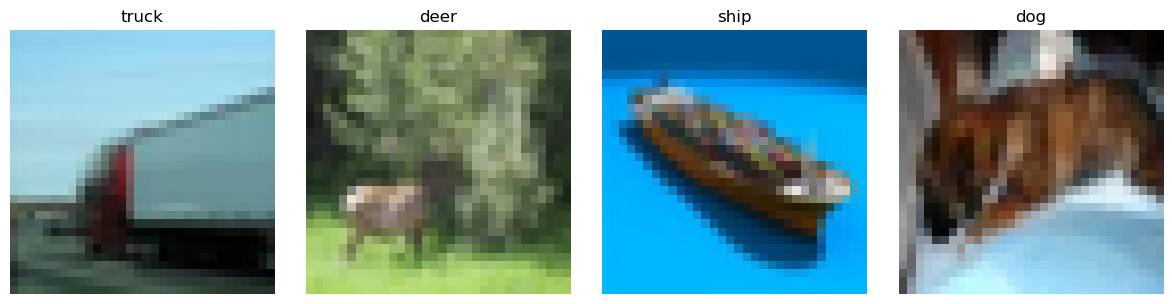

In [8]:
dataiter = iter(trainloader)
images, labels = next(dataiter)

fig, axes = plt.subplots(1, 4, figsize=(12, 3))

for i in range(4):
    axes[i].imshow(imshow(images[i]))
    axes[i].set_title(
        trainset.classes[labels[i].item()]
    )
    axes[i].axis("off")

plt.tight_layout()
plt.show()

### 9.Basic Plain Block 구현

In [9]:
class BasicPlainBlock(nn.Module):
    expansion = 1

    def __init__(
        self,
        in_channels,
        out_channels,
        stride=1
    ):
        super(BasicPlainBlock, self).__init__()

        self.conv1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            in_channels=out_channels,
            out_channels=out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.bn2 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = F.relu(out)

        return out

### 10.Basic Plain Block 확인

In [10]:
plain_basic_block = BasicPlainBlock(
    in_channels=64,
    out_channels=64,
    stride=1
)

plain_basic_block

BasicPlainBlock(
  (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)

In [11]:
dummy_input = torch.zeros(
    1,
    64,
    32,
    32
)

plain_basic_output = plain_basic_block(
    dummy_input
)

print(f"Input shape: {dummy_input.shape}")
print(f"Output shape: {plain_basic_output.shape}")

Input shape: torch.Size([1, 64, 32, 32])
Output shape: torch.Size([1, 64, 32, 32])


### 11.BasicResidual Block 구현

In [12]:
class BasicResidualBlock(nn.Module):
    expansion = 1

    def __init__(
        self,
        in_channels,
        out_channels,
        stride=1
    ):
        super(BasicResidualBlock, self).__init__()

        self.conv1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            in_channels=out_channels,
            out_channels=out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()

        if (
            stride != 1
            or in_channels != out_channels
        ):
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels=in_channels,
                    out_channels=out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),

                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + identity
        out = F.relu(out)

        return out

### 12.Basic Residual Block 확인

In [13]:
residual_basic_block = BasicResidualBlock(
    in_channels=64,
    out_channels=128,
    stride=2
)

residual_basic_block

BasicResidualBlock(
  (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (shortcut): Sequential(
    (0): Conv2d(64, 128, kernel_size=(1, 1), stride=(2, 2), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)

In [14]:
dummy_input = torch.zeros(
    1,
    64,
    32,
    32
)

residual_basic_output = residual_basic_block(
    dummy_input
)

print(f"Input shape: {dummy_input.shape}")
print(f"Output shape: {residual_basic_output.shape}")

Input shape: torch.Size([1, 64, 32, 32])
Output shape: torch.Size([1, 128, 16, 16])


### 13.ResNet-50 Plain Bottleneck Block 구현

In [15]:
class BottleneckPlainBlock(nn.Module):
    expansion = 4

    def __init__(
        self,
        in_channels,
        out_channels,
        stride=1
    ):
        super(BottleneckPlainBlock, self).__init__()

        self.conv1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=1,
            stride=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            in_channels=out_channels,
            out_channels=out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )

        self.bn2 = nn.BatchNorm2d(out_channels)

        self.conv3 = nn.Conv2d(
            in_channels=out_channels,
            out_channels=(
                out_channels * self.expansion
            ),
            kernel_size=1,
            stride=1,
            bias=False
        )

        self.bn3 = nn.BatchNorm2d(
            out_channels * self.expansion
        )

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = F.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)
        out = F.relu(out)

        return out

### 14.Plain Bottleneck Block 확인

In [16]:
plain_bottleneck_block = BottleneckPlainBlock(
    in_channels=64,
    out_channels=64,
    stride=1
)

plain_bottleneck_block

BottleneckPlainBlock(
  (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)

In [17]:
dummy_input = torch.zeros(
    1,
    64,
    32,
    32
)

plain_bottleneck_output = (
    plain_bottleneck_block(dummy_input)
)

print(f"Input shape: {dummy_input.shape}")
print(
    f"Output shape: "
    f"{plain_bottleneck_output.shape}"
)

Input shape: torch.Size([1, 64, 32, 32])
Output shape: torch.Size([1, 256, 32, 32])


### 15.ResNet-50 Residual Bottleneck Block 구현

In [18]:
class BottleneckResidualBlock(nn.Module):
    expansion = 4

    def __init__(
        self,
        in_channels,
        out_channels,
        stride=1
    ):
        super(
            BottleneckResidualBlock,
            self
        ).__init__()

        self.conv1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=1,
            stride=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            in_channels=out_channels,
            out_channels=out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )

        self.bn2 = nn.BatchNorm2d(out_channels)

        self.conv3 = nn.Conv2d(
            in_channels=out_channels,
            out_channels=(
                out_channels * self.expansion
            ),
            kernel_size=1,
            stride=1,
            bias=False
        )

        self.bn3 = nn.BatchNorm2d(
            out_channels * self.expansion
        )

        self.shortcut = nn.Sequential()

        if (
            stride != 1
            or in_channels
            != out_channels * self.expansion
        ):
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels=in_channels,
                    out_channels=(
                        out_channels
                        * self.expansion
                    ),
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),

                nn.BatchNorm2d(
                    out_channels
                    * self.expansion
                )
            )

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = F.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        out = out + identity
        out = F.relu(out)

        return out

### 16.Residual Bottleneck Block 확인

In [19]:
residual_bottleneck_block = (
    BottleneckResidualBlock(
        in_channels=64,
        out_channels=64,
        stride=1
    )
)

residual_bottleneck_block

BottleneckResidualBlock(
  (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (shortcut): Sequential(
    (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)

In [20]:
dummy_input = torch.zeros(
    1,
    64,
    32,
    32
)

residual_bottleneck_output = (
    residual_bottleneck_block(dummy_input)
)

print(f"Input shape: {dummy_input.shape}")
print(
    f"Output shape: "
    f"{residual_bottleneck_output.shape}"
)

Input shape: torch.Size([1, 64, 32, 32])
Output shape: torch.Size([1, 256, 32, 32])


## ResNet

### 17.전체 네트워크 구현

In [21]:
class ResNet(nn.Module):
    def __init__(
        self,
        block,
        num_blocks,
        num_classes=10
    ):
        super(ResNet, self).__init__()

        self.in_channels = 64

        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=64,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(64)

        self.layer1 = self.make_layer(
            block=block,
            out_channels=64,
            num_blocks=num_blocks[0],
            stride=1
        )

        self.layer2 = self.make_layer(
            block=block,
            out_channels=128,
            num_blocks=num_blocks[1],
            stride=2
        )

        self.layer3 = self.make_layer(
            block=block,
            out_channels=256,
            num_blocks=num_blocks[2],
            stride=2
        )

        self.layer4 = self.make_layer(
            block=block,
            out_channels=512,
            num_blocks=num_blocks[3],
            stride=2
        )

        self.avg_pool = nn.AdaptiveAvgPool2d(
            output_size=(1, 1)
        )

        self.fc = nn.Linear(
            in_features=(
                512 * block.expansion
            ),
            out_features=num_classes
        )

    def make_layer(
        self,
        block,
        out_channels,
        num_blocks,
        stride
    ):
        layers = []

        layers.append(
            block(
                in_channels=self.in_channels,
                out_channels=out_channels,
                stride=stride
            )
        )

        self.in_channels = (
            out_channels * block.expansion
        )

        for _ in range(1, num_blocks):
            layers.append(
                block(
                    in_channels=self.in_channels,
                    out_channels=out_channels,
                    stride=1
                )
            )

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avg_pool(x)

        x = torch.flatten(x, 1)

        x = self.fc(x)

        return x

### 18.모델 생성 함수

In [22]:
def plainnet34():
    return ResNet(
        block=BasicPlainBlock,
        num_blocks=[3, 4, 6, 3],
        num_classes=10
    )


def resnet34():
    return ResNet(
        block=BasicResidualBlock,
        num_blocks=[3, 4, 6, 3],
        num_classes=10
    )


def plainnet50():
    return ResNet(
        block=BottleneckPlainBlock,
        num_blocks=[3, 4, 6, 3],
        num_classes=10
    )


def resnet50():
    return ResNet(
        block=BottleneckResidualBlock,
        num_blocks=[3, 4, 6, 3],
        num_classes=10
    )

### 19.모델 생성

In [23]:
plain_model_34 = plainnet34()
residual_model_34 = resnet34()

plain_model_50 = plainnet50()
residual_model_50 = resnet50()

### 20.모델 출력 확인

In [24]:
dummy_input = torch.zeros(
    1,
    3,
    32,
    32
)

plain_output_34 = plain_model_34(
    dummy_input
)

residual_output_34 = residual_model_34(
    dummy_input
)

plain_output_50 = plain_model_50(
    dummy_input
)

residual_output_50 = residual_model_50(
    dummy_input
)

print(
    "PlainNet-34 output shape:",
    plain_output_34.shape
)

print(
    "ResNet-34 output shape:",
    residual_output_34.shape
)

print(
    "PlainNet-50 output shape:",
    plain_output_50.shape
)

print(
    "ResNet-50 output shape:",
    residual_output_50.shape
)

PlainNet-34 output shape: torch.Size([1, 10])
ResNet-34 output shape: torch.Size([1, 10])
PlainNet-50 output shape: torch.Size([1, 10])
ResNet-50 output shape: torch.Size([1, 10])


## Model Summary

### 21.PlainNet-34 Summary

In [25]:
summary(
    plain_model_34,
    input_size=(1, 3, 32, 32),
    device="cpu"
)

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 10]                   --
├─Conv2d: 1-1                            [1, 64, 32, 32]           1,728
├─BatchNorm2d: 1-2                       [1, 64, 32, 32]           128
├─Sequential: 1-3                        [1, 64, 32, 32]           --
│    └─BasicPlainBlock: 2-1              [1, 64, 32, 32]           --
│    │    └─Conv2d: 3-1                  [1, 64, 32, 32]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 32, 32]           128
│    │    └─Conv2d: 3-3                  [1, 64, 32, 32]           36,864
│    │    └─BatchNorm2d: 3-4             [1, 64, 32, 32]           128
│    └─BasicPlainBlock: 2-2              [1, 64, 32, 32]           --
│    │    └─Conv2d: 3-5                  [1, 64, 32, 32]           36,864
│    │    └─BatchNorm2d: 3-6             [1, 64, 32, 32]           128
│    │    └─Conv2d: 3-7                  [1, 64, 32, 32]          

### 22.ResNet-34 Summary

In [26]:
summary(
    residual_model_34,
    input_size=(1, 3, 32, 32),
    device="cpu"
)

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 10]                   --
├─Conv2d: 1-1                            [1, 64, 32, 32]           1,728
├─BatchNorm2d: 1-2                       [1, 64, 32, 32]           128
├─Sequential: 1-3                        [1, 64, 32, 32]           --
│    └─BasicResidualBlock: 2-1           [1, 64, 32, 32]           --
│    │    └─Sequential: 3-1              [1, 64, 32, 32]           --
│    │    └─Conv2d: 3-2                  [1, 64, 32, 32]           36,864
│    │    └─BatchNorm2d: 3-3             [1, 64, 32, 32]           128
│    │    └─Conv2d: 3-4                  [1, 64, 32, 32]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 32, 32]           128
│    └─BasicResidualBlock: 2-2           [1, 64, 32, 32]           --
│    │    └─Sequential: 3-6              [1, 64, 32, 32]           --
│    │    └─Conv2d: 3-7                  [1, 64, 32, 32]           36,8

### 23.PlainNet-50 Summary

In [27]:
summary(
    plain_model_50,
    input_size=(1, 3, 32, 32),
    device="cpu"
)

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 10]                   --
├─Conv2d: 1-1                            [1, 64, 32, 32]           1,728
├─BatchNorm2d: 1-2                       [1, 64, 32, 32]           128
├─Sequential: 1-3                        [1, 256, 32, 32]          --
│    └─BottleneckPlainBlock: 2-1         [1, 256, 32, 32]          --
│    │    └─Conv2d: 3-1                  [1, 64, 32, 32]           4,096
│    │    └─BatchNorm2d: 3-2             [1, 64, 32, 32]           128
│    │    └─Conv2d: 3-3                  [1, 64, 32, 32]           36,864
│    │    └─BatchNorm2d: 3-4             [1, 64, 32, 32]           128
│    │    └─Conv2d: 3-5                  [1, 256, 32, 32]          16,384
│    │    └─BatchNorm2d: 3-6             [1, 256, 32, 32]          512
│    └─BottleneckPlainBlock: 2-2         [1, 256, 32, 32]          --
│    │    └─Conv2d: 3-7                  [1, 64, 32, 32]           

### 24.ResNet-50 Summary

In [28]:
summary(
    residual_model_50,
    input_size=(1, 3, 32, 32),
    device="cpu"
)

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 10]                   --
├─Conv2d: 1-1                            [1, 64, 32, 32]           1,728
├─BatchNorm2d: 1-2                       [1, 64, 32, 32]           128
├─Sequential: 1-3                        [1, 256, 32, 32]          --
│    └─BottleneckResidualBlock: 2-1      [1, 256, 32, 32]          --
│    │    └─Sequential: 3-1              [1, 256, 32, 32]          16,896
│    │    └─Conv2d: 3-2                  [1, 64, 32, 32]           4,096
│    │    └─BatchNorm2d: 3-3             [1, 64, 32, 32]           128
│    │    └─Conv2d: 3-4                  [1, 64, 32, 32]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 32, 32]           128
│    │    └─Conv2d: 3-6                  [1, 256, 32, 32]          16,384
│    │    └─BatchNorm2d: 3-7             [1, 256, 32, 32]          512
│    └─BottleneckResidualBlock: 2-2      [1, 256, 32, 32]      

## Dataset Information

### 25. 원본 데이터셋 정보 확인

In [44]:
print("========== CIFAR-10 Dataset ==========")

print(f"Number of Training Images : {len(trainset):,}")
print(f"Number of Test Images     : {len(testset):,}")

print(f"Number of Classes         : {len(trainset.classes)}")

print("\nClass Names")

for idx, class_name in enumerate(trainset.classes):
    print(f"{idx:2d} : {class_name}")

========== CIFAR-10 Dataset ==========
Number of Training Images : 50,000
Number of Test Images     : 10,000
Number of Classes         : 10

Class Names
 0 : airplane
 1 : automobile
 2 : bird
 3 : cat
 4 : deer
 5 : dog
 6 : frog
 7 : horse
 8 : ship
 9 : truck


### 26.실제 실험에 사용된 데이터셋

In [ ]:
print("\n========== Dataset Used in Experiment ==========")
print(f"Training Samples : {len(train_subset):,}")
print(f"Test Samples     : {len(test_subset):,}")
print(f"Training Batches : {len(trainloader)}")
print(f"Test Batches     : {len(testloader)}")

## Hyperparameter

### 27.학습 설정

In [33]:
BATCH_SIZE = 64
EPOCH = 3

LEARNING_RATE = 0.01
MOMENTUM = 0.9
WEIGHT_DECAY = 1e-4

## 7. DataLoader

DataLoader를 생성하여 데이터를 Mini-batch 단위로 학습할 수 있도록 구성한다.
CPU 환경에서 학습 시간을 줄이기 위해 CIFAR-10 데이터셋의 일부를 선택하여 사용하였다.
모든 모델이 동일한 데이터셋을 사용하도록 설정하여 공정한 비교를 수행하였다.

### 28.학습용 DataLoader 생성

In [46]:
train_subset = Subset(
    trainset,
    range(5000)
)

test_subset = Subset(
    testset,
    range(1000)
)

trainloader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

testloader = DataLoader(
    test_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print(f"Batch Size: {BATCH_SIZE}")
print(f"Epoch: {EPOCH}")
print(f"Training Samples: {len(train_subset)}")
print(f"Test Samples: {len(test_subset)}")
print(f"Number of Classes: {len(trainset.classes)}")
print(f"Number of Training Batches: {len(trainloader)}")
print(f"Number of Test Batches: {len(testloader)}")

Batch Size: 64
Epoch: 3
Training Samples: 5000
Test Samples: 1000
Number of Classes: 10
Number of Training Batches: 79
Number of Test Batches: 16


### 29.PlainNet-34 Training

-> 시간이 너무 오래걸려서 어느정도 진행되는지 알기 위해 CPU에서 진행 상황이 안 보이는 문제를 해결하도록 첫 배치부터 출력하고, 배치마다 텐서를 정리하며, epoch 시간까지 확인하게 만들었다.

In [35]:
# device 정의
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)
print("Training batches:", len(trainloader))
print("Test batches:", len(testloader))

gc.collect()

current_time = time.time()

plain_model_34 = plainnet34()
plain_model_34 = plain_model_34.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    plain_model_34.parameters(),
    lr=LEARNING_RATE,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY
)

plain34_train_losses = []
plain34_val_accuracy = []

for epoch in range(EPOCH):
    epoch_start_time = time.time()

    plain_model_34.train()

    running_loss = 0.0
    train_correct = 0
    train_total = 0

    print(
        f"\nEpoch [{epoch + 1}/{EPOCH}] 시작",
        flush=True
    )

    for i, data in enumerate(trainloader):
        batch_start_time = time.time()

        inputs, labels = data

        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = plain_model_34(inputs)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)

        train_correct += (
            predicted == labels
        ).sum().item()

        # 첫 배치와 이후 5배치마다 출력
        if i == 0 or (i + 1) % 5 == 0:
            print(
                f"Epoch [{epoch + 1}/{EPOCH}], "
                f"Batch [{i + 1}/{len(trainloader)}], "
                f"Loss: {loss.item():.4f}, "
                f"Batch Time: "
                f"{time.time() - batch_start_time:.2f}초",
                flush=True
            )

        del inputs, labels, outputs, loss, predicted

    epoch_loss = running_loss / len(trainloader)

    train_accuracy = (
        100 * train_correct / train_total
    )

    plain34_train_losses.append(epoch_loss)

    print("Validation 시작", flush=True)

    plain_model_34.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for i, data in enumerate(testloader):
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = plain_model_34(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

            if i == 0 or (i + 1) % 5 == 0:
                print(
                    f"Validation Batch "
                    f"[{i + 1}/{len(testloader)}]",
                    flush=True
                )

            del images, labels, outputs, predicted

    validation_accuracy = (
        100 * correct / total
    )

    plain34_val_accuracy.append(
        validation_accuracy
    )

    print(
        f"\nEpoch [{epoch + 1}/{EPOCH}] 완료\n"
        f"Training Loss: {epoch_loss:.4f}\n"
        f"Training Accuracy: {train_accuracy:.2f}%\n"
        f"Validation Accuracy: "
        f"{validation_accuracy:.2f}%\n"
        f"Epoch Time: "
        f"{time.time() - epoch_start_time:.2f}초",
        flush=True
    )

print("\nFinished PlainNet-34 Training")

print(
    f"Total Training Time: "
    f"{time.time() - current_time:.2f} seconds"
)

Device: cpu
Training batches: 79
Test batches: 16

Epoch [1/3] 시작
Epoch [1/3], Batch [1/79], Loss: 2.3206, Batch Time: 9.55초
Epoch [1/3], Batch [5/79], Loss: 2.3335, Batch Time: 9.35초
Epoch [1/3], Batch [10/79], Loss: 2.3626, Batch Time: 9.35초
Epoch [1/3], Batch [15/79], Loss: 2.3357, Batch Time: 9.33초
Epoch [1/3], Batch [20/79], Loss: 2.2005, Batch Time: 9.50초
Epoch [1/3], Batch [25/79], Loss: 2.3350, Batch Time: 9.50초
Epoch [1/3], Batch [30/79], Loss: 2.1289, Batch Time: 9.51초
Epoch [1/3], Batch [35/79], Loss: 2.3294, Batch Time: 9.28초
Epoch [1/3], Batch [40/79], Loss: 2.1944, Batch Time: 9.31초
Epoch [1/3], Batch [45/79], Loss: 2.0959, Batch Time: 9.57초
Epoch [1/3], Batch [50/79], Loss: 2.1069, Batch Time: 9.32초
Epoch [1/3], Batch [55/79], Loss: 2.1438, Batch Time: 9.57초
Epoch [1/3], Batch [60/79], Loss: 2.3462, Batch Time: 9.45초
Epoch [1/3], Batch [65/79], Loss: 2.1874, Batch Time: 9.37초
Epoch [1/3], Batch [70/79], Loss: 2.0536, Batch Time: 9.74초
Epoch [1/3], Batch [75/79], Loss: 2.

### 30.PlainNet-34 Training Loss 그래프

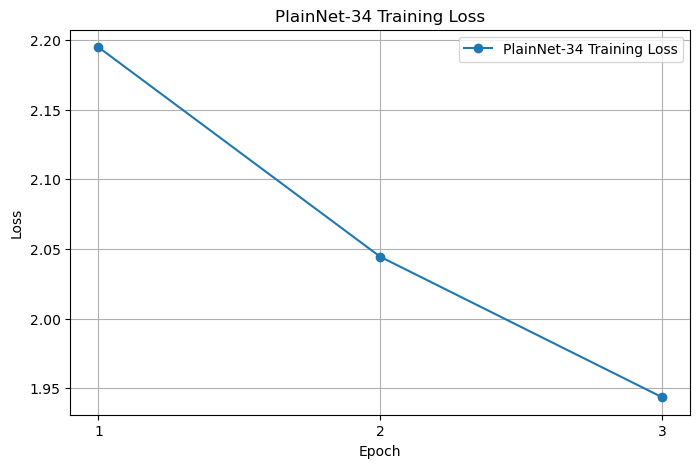

In [36]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCH + 1),
    plain34_train_losses,
    marker="o",
    label="PlainNet-34 Training Loss"
)

plt.title("PlainNet-34 Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.xticks(range(1, EPOCH + 1))

plt.legend()
plt.grid()
plt.show()

### 31.PlainNet-34 Validation Accuracy 그래프

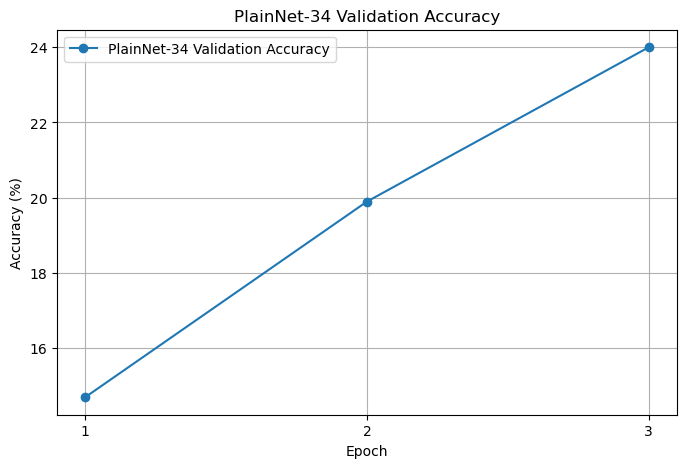

In [37]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCH + 1),
    plain34_val_accuracy,
    marker="o",
    label="PlainNet-34 Validation Accuracy"
)

plt.title("PlainNet-34 Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.xticks(range(1, EPOCH + 1))

plt.legend()
plt.grid()
plt.show()

### 32.ResNet-34 Training

In [38]:
gc.collect()

current_time = time.time()

residual_model_34 = resnet34()
residual_model_34 = residual_model_34.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    residual_model_34.parameters(),
    lr=LEARNING_RATE,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY
)

resnet34_train_losses = []
resnet34_val_accuracy = []

print("Device:", device)
print("Training Batches:", len(trainloader))
print("Test Batches:", len(testloader))

for epoch in range(EPOCH):
    epoch_start_time = time.time()

    residual_model_34.train()

    running_loss = 0.0
    train_correct = 0
    train_total = 0

    print(
        f"\nEpoch [{epoch + 1}/{EPOCH}] 시작",
        flush=True
    )

    for i, data in enumerate(trainloader):
        batch_start_time = time.time()

        inputs, labels = data

        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = residual_model_34(inputs)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)

        train_correct += (
            predicted == labels
        ).sum().item()

        # 첫 배치와 이후 5배치마다 출력
        if i == 0 or (i + 1) % 5 == 0:
            print(
                f"Epoch [{epoch + 1}/{EPOCH}], "
                f"Batch [{i + 1}/{len(trainloader)}], "
                f"Loss: {loss.item():.4f}, "
                f"Batch Time: "
                f"{time.time() - batch_start_time:.2f}초",
                flush=True
            )

        del inputs, labels, outputs, loss, predicted

    epoch_loss = (
        running_loss / len(trainloader)
    )

    train_accuracy = (
        100 * train_correct / train_total
    )

    resnet34_train_losses.append(
        epoch_loss
    )

    print(
        "Validation 시작",
        flush=True
    )

    residual_model_34.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for i, data in enumerate(testloader):
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = residual_model_34(images)

            _, predicted = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

            # 검증 진행 상황 출력
            if i == 0 or (i + 1) % 5 == 0:
                print(
                    f"Validation Batch "
                    f"[{i + 1}/{len(testloader)}]",
                    flush=True
                )

            del images, labels, outputs, predicted

    validation_accuracy = (
        100 * correct / total
    )

    resnet34_val_accuracy.append(
        validation_accuracy
    )

    print(
        f"\nEpoch [{epoch + 1}/{EPOCH}] 완료\n"
        f"Training Loss: {epoch_loss:.4f}\n"
        f"Training Accuracy: {train_accuracy:.2f}%\n"
        f"Validation Accuracy: "
        f"{validation_accuracy:.2f}%\n"
        f"Epoch Time: "
        f"{time.time() - epoch_start_time:.2f}초",
        flush=True
    )

    gc.collect()

print("\nFinished ResNet-34 Training")

print(
    f"Total Training Time: "
    f"{time.time() - current_time:.2f} seconds"
)

Device: cpu
Training Batches: 79
Test Batches: 16

Epoch [1/3] 시작
Epoch [1/3], Batch [1/79], Loss: 2.3752, Batch Time: 9.91초
Epoch [1/3], Batch [5/79], Loss: 2.7807, Batch Time: 9.72초
Epoch [1/3], Batch [10/79], Loss: 2.4096, Batch Time: 9.57초
Epoch [1/3], Batch [15/79], Loss: 2.0773, Batch Time: 9.53초
Epoch [1/3], Batch [20/79], Loss: 1.9177, Batch Time: 9.65초
Epoch [1/3], Batch [25/79], Loss: 2.4108, Batch Time: 9.40초
Epoch [1/3], Batch [30/79], Loss: 2.1300, Batch Time: 10.22초
Epoch [1/3], Batch [35/79], Loss: 1.9872, Batch Time: 9.70초
Epoch [1/3], Batch [40/79], Loss: 2.1747, Batch Time: 9.43초
Epoch [1/3], Batch [45/79], Loss: 2.2227, Batch Time: 9.75초
Epoch [1/3], Batch [50/79], Loss: 1.9619, Batch Time: 9.48초
Epoch [1/3], Batch [55/79], Loss: 2.1383, Batch Time: 10.09초
Epoch [1/3], Batch [60/79], Loss: 1.7928, Batch Time: 9.68초
Epoch [1/3], Batch [65/79], Loss: 1.7936, Batch Time: 9.59초
Epoch [1/3], Batch [70/79], Loss: 1.7519, Batch Time: 9.81초
Epoch [1/3], Batch [75/79], Loss: 

### 33.ResNet-34 Training Loss 그래프

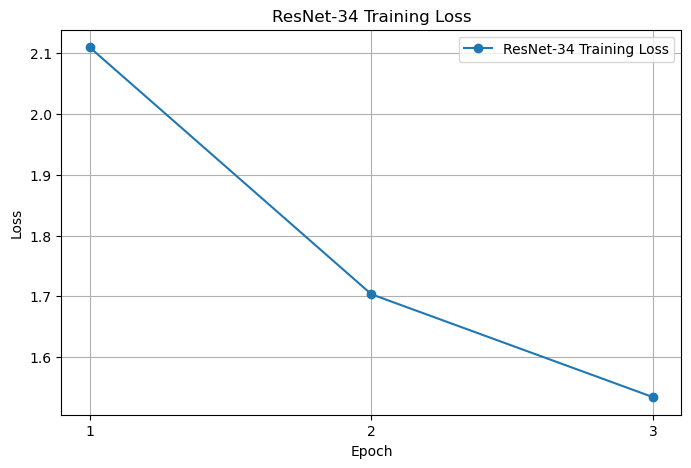

In [39]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCH + 1),
    resnet34_train_losses,
    marker="o",
    label="ResNet-34 Training Loss"
)

plt.title("ResNet-34 Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.xticks(range(1, EPOCH + 1))

plt.legend()
plt.grid()
plt.show()

### 34.ResNet-34 Validation Accuracy 그래프

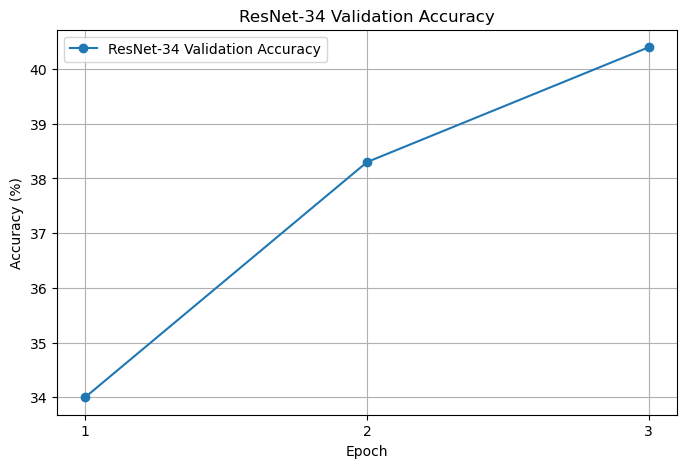

In [40]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCH + 1),
    resnet34_val_accuracy,
    marker="o",
    label="ResNet-34 Validation Accuracy"
)

plt.title("ResNet-34 Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.xticks(range(1, EPOCH + 1))

plt.legend()
plt.grid()
plt.show()

### 35.PlainNet-34와 ResNet-34 Loss 비교

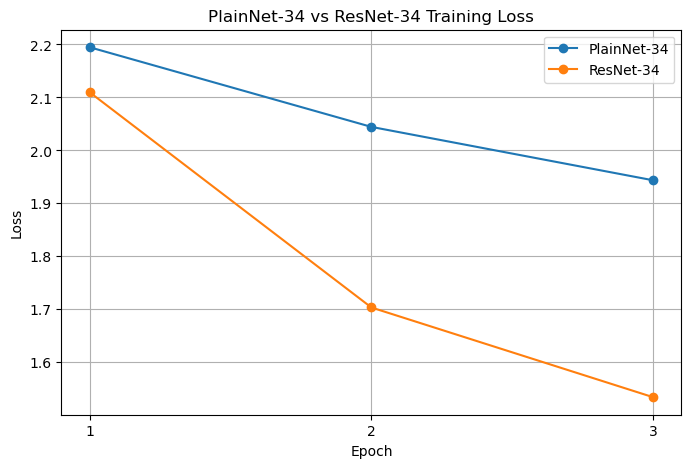

In [41]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCH + 1),
    plain34_train_losses,
    marker="o",
    label="PlainNet-34"
)

plt.plot(
    range(1, EPOCH + 1),
    resnet34_train_losses,
    marker="o",
    label="ResNet-34"
)

plt.title(
    "PlainNet-34 vs ResNet-34 Training Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.xticks(range(1, EPOCH + 1))

plt.legend()
plt.grid()
plt.show()

### 36.PlainNet-34와 ResNet-34 Validation Accuracy

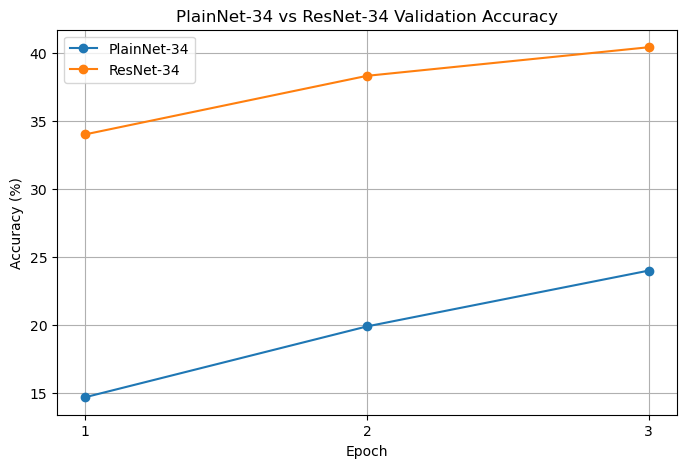

In [42]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCH + 1),
    plain34_val_accuracy,
    marker="o",
    label="PlainNet-34"
)

plt.plot(
    range(1, EPOCH + 1),
    resnet34_val_accuracy,
    marker="o",
    label="ResNet-34"
)

plt.title(
    "PlainNet-34 vs ResNet-34 "
    "Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.xticks(range(1, EPOCH + 1))

plt.legend()
plt.grid()
plt.show()

### 37.PlainNet-50 Training

In [43]:
gc.collect()

current_time = time.time()

plain_model_50 = plainnet50()
plain_model_50 = plain_model_50.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    plain_model_50.parameters(),
    lr=LEARNING_RATE,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY
)

plain50_train_losses = []
plain50_val_accuracy = []

print("Device:", device)
print("Training Batches:", len(trainloader))
print("Test Batches:", len(testloader))

for epoch in range(EPOCH):

    epoch_start_time = time.time()

    plain_model_50.train()

    running_loss = 0.0
    train_correct = 0
    train_total = 0

    print(f"\nEpoch [{epoch + 1}/{EPOCH}] 시작", flush=True)

    for i, data in enumerate(trainloader):

        batch_start_time = time.time()

        inputs, labels = data

        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = plain_model_50(inputs)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)

        train_correct += (predicted == labels).sum().item()

        if i == 0 or (i + 1) % 5 == 0:
            print(
                f"Epoch [{epoch + 1}/{EPOCH}], "
                f"Batch [{i + 1}/{len(trainloader)}], "
                f"Loss: {loss.item():.4f}, "
                f"Batch Time: {time.time() - batch_start_time:.2f}초",
                flush=True
            )

        del inputs, labels, outputs, loss, predicted

    epoch_loss = running_loss / len(trainloader)

    train_accuracy = 100 * train_correct / train_total

    plain50_train_losses.append(epoch_loss)

    print("Validation 시작", flush=True)

    plain_model_50.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for i, data in enumerate(testloader):

            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = plain_model_50(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

            if i == 0 or (i + 1) % 5 == 0:
                print(
                    f"Validation Batch [{i + 1}/{len(testloader)}]",
                    flush=True
                )

            del images, labels, outputs, predicted

    validation_accuracy = 100 * correct / total

    plain50_val_accuracy.append(validation_accuracy)

    print(
        f"\nEpoch [{epoch + 1}/{EPOCH}] 완료\n"
        f"Training Loss: {epoch_loss:.4f}\n"
        f"Training Accuracy: {train_accuracy:.2f}%\n"
        f"Validation Accuracy: {validation_accuracy:.2f}%\n"
        f"Epoch Time: {time.time() - epoch_start_time:.2f}초",
        flush=True
    )

    gc.collect()

print("\nFinished PlainNet-50 Training")

print(
    f"Total Training Time: "
    f"{time.time() - current_time:.2f} seconds"
)

Device: cpu
Training Batches: 79
Test Batches: 16

Epoch [1/3] 시작
Epoch [1/3], Batch [1/79], Loss: 2.3615, Batch Time: 16.00초
Epoch [1/3], Batch [5/79], Loss: 2.3292, Batch Time: 14.64초
Epoch [1/3], Batch [10/79], Loss: 2.2717, Batch Time: 12.53초
Epoch [1/3], Batch [15/79], Loss: 2.6035, Batch Time: 11.43초
Epoch [1/3], Batch [20/79], Loss: 2.6268, Batch Time: 11.96초
Epoch [1/3], Batch [25/79], Loss: 2.5465, Batch Time: 10.85초
Epoch [1/3], Batch [30/79], Loss: 2.5183, Batch Time: 11.37초
Epoch [1/3], Batch [35/79], Loss: 2.7529, Batch Time: 11.57초
Epoch [1/3], Batch [40/79], Loss: 2.5056, Batch Time: 11.94초
Epoch [1/3], Batch [45/79], Loss: 2.3492, Batch Time: 11.17초
Epoch [1/3], Batch [50/79], Loss: 2.2919, Batch Time: 11.55초
Epoch [1/3], Batch [55/79], Loss: 2.2860, Batch Time: 12.08초
Epoch [1/3], Batch [60/79], Loss: 2.3776, Batch Time: 11.21초
Epoch [1/3], Batch [65/79], Loss: 2.6671, Batch Time: 12.10초
Epoch [1/3], Batch [70/79], Loss: 2.4304, Batch Time: 11.13초
Epoch [1/3], Batch [7

### 38.PlainNet-50 Training Loss

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(plain50_train_losses) + 1),
    plain50_train_losses,
    marker="o",
    label="PlainNet-50"
)

plt.title("PlainNet-50 Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(range(1, len(plain50_train_losses) + 1))
plt.grid()
plt.legend()
plt.show()

### 39.PlainNet-50 Validation Accuracy

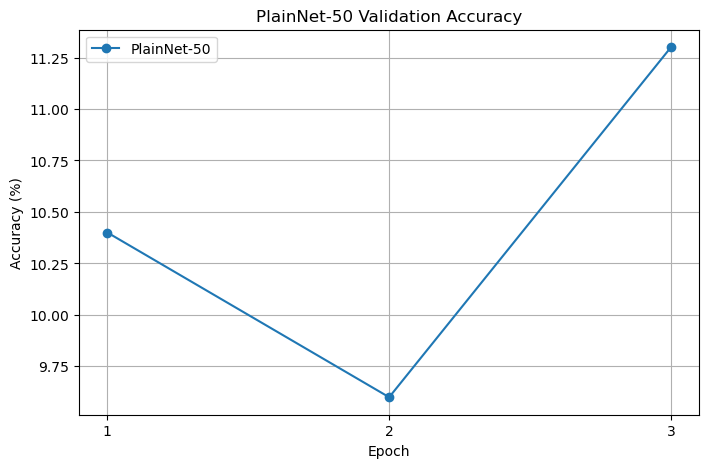

In [47]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(plain50_val_accuracy) + 1),
    plain50_val_accuracy,
    marker="o",
    label="PlainNet-50"
)

plt.title("PlainNet-50 Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.xticks(range(1, len(plain50_val_accuracy) + 1))
plt.grid()
plt.legend()
plt.show()

### 40.ResNet-50 Training

In [48]:
gc.collect()

current_time = time.time()

residual_model_50 = resnet50()
residual_model_50 = residual_model_50.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    residual_model_50.parameters(),
    lr=LEARNING_RATE,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY
)

resnet50_train_losses = []
resnet50_val_accuracy = []

print("Device:", device)
print("Training Batches:", len(trainloader))
print("Test Batches:", len(testloader))

for epoch in range(EPOCH):
    epoch_start_time = time.time()

    residual_model_50.train()

    running_loss = 0.0
    train_correct = 0
    train_total = 0

    print(
        f"\nEpoch [{epoch + 1}/{EPOCH}] 시작",
        flush=True
    )

    for i, data in enumerate(trainloader):
        batch_start_time = time.time()

        inputs, labels = data

        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = residual_model_50(inputs)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)

        train_correct += (
            predicted == labels
        ).sum().item()

        if i == 0 or (i + 1) % 5 == 0:
            print(
                f"Epoch [{epoch + 1}/{EPOCH}], "
                f"Batch [{i + 1}/{len(trainloader)}], "
                f"Loss: {loss.item():.4f}, "
                f"Batch Time: "
                f"{time.time() - batch_start_time:.2f}초",
                flush=True
            )

        del inputs, labels, outputs, loss, predicted

    epoch_loss = running_loss / len(trainloader)

    train_accuracy = (
        100 * train_correct / train_total
    )

    resnet50_train_losses.append(epoch_loss)

    print("Validation 시작", flush=True)

    residual_model_50.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for i, data in enumerate(testloader):
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = residual_model_50(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

            if i == 0 or (i + 1) % 5 == 0:
                print(
                    f"Validation Batch "
                    f"[{i + 1}/{len(testloader)}]",
                    flush=True
                )

            del images, labels, outputs, predicted

    validation_accuracy = (
        100 * correct / total
    )

    resnet50_val_accuracy.append(
        validation_accuracy
    )

    print(
        f"\nEpoch [{epoch + 1}/{EPOCH}] 완료\n"
        f"Training Loss: {epoch_loss:.4f}\n"
        f"Training Accuracy: {train_accuracy:.2f}%\n"
        f"Validation Accuracy: "
        f"{validation_accuracy:.2f}%\n"
        f"Epoch Time: "
        f"{time.time() - epoch_start_time:.2f}초",
        flush=True
    )

    gc.collect()

print("\nFinished ResNet-50 Training")

print(
    f"Total Training Time: "
    f"{time.time() - current_time:.2f} seconds"
)

Device: cpu
Training Batches: 79
Test Batches: 16

Epoch [1/3] 시작
Epoch [1/3], Batch [1/79], Loss: 2.5243, Batch Time: 14.60초
Epoch [1/3], Batch [5/79], Loss: 4.6979, Batch Time: 13.73초
Epoch [1/3], Batch [10/79], Loss: 5.0593, Batch Time: 13.00초
Epoch [1/3], Batch [15/79], Loss: 4.2148, Batch Time: 12.72초
Epoch [1/3], Batch [20/79], Loss: 4.6848, Batch Time: 12.46초
Epoch [1/3], Batch [25/79], Loss: 4.1638, Batch Time: 12.60초
Epoch [1/3], Batch [30/79], Loss: 3.5056, Batch Time: 12.96초
Epoch [1/3], Batch [35/79], Loss: 2.7316, Batch Time: 12.50초
Epoch [1/3], Batch [40/79], Loss: 2.4478, Batch Time: 14.13초
Epoch [1/3], Batch [45/79], Loss: 2.3395, Batch Time: 12.52초
Epoch [1/3], Batch [50/79], Loss: 2.3532, Batch Time: 12.32초
Epoch [1/3], Batch [55/79], Loss: 3.2971, Batch Time: 13.49초
Epoch [1/3], Batch [60/79], Loss: 2.2246, Batch Time: 13.03초
Epoch [1/3], Batch [65/79], Loss: 2.4872, Batch Time: 12.77초
Epoch [1/3], Batch [70/79], Loss: 2.3336, Batch Time: 13.37초
Epoch [1/3], Batch [7

### 41.ResNet-50 Training Loss

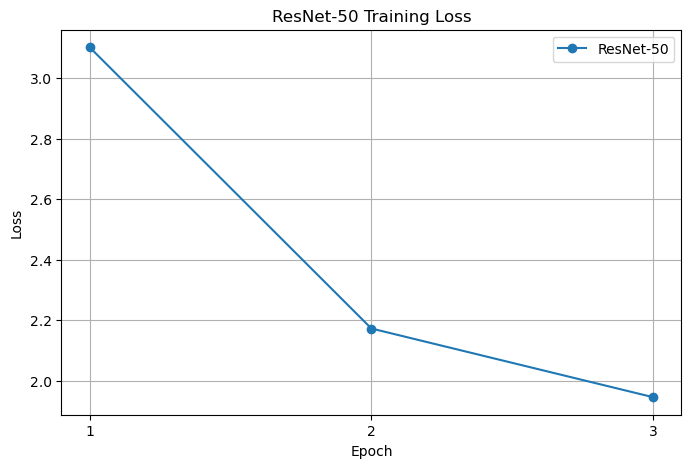

In [49]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(resnet50_train_losses) + 1),
    resnet50_train_losses,
    marker="o",
    label="ResNet-50"
)

plt.title("ResNet-50 Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(range(1, len(resnet50_train_losses) + 1))
plt.grid()
plt.legend()
plt.show()

### 42.ResNet-50 Validation Accuracy

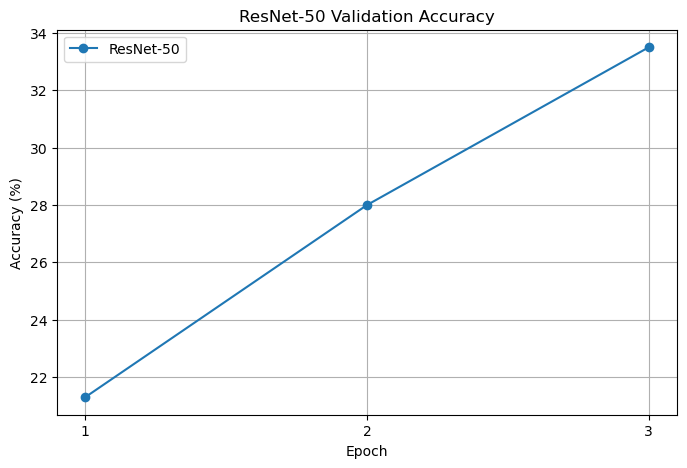

In [50]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(resnet50_val_accuracy) + 1),
    resnet50_val_accuracy,
    marker="o",
    label="ResNet-50"
)

plt.title("ResNet-50 Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.xticks(range(1, len(resnet50_val_accuracy) + 1))
plt.grid()
plt.legend()
plt.show()

## Model Comparison

### 43.PlainNet-34 vs ResNet-34 Training Loss

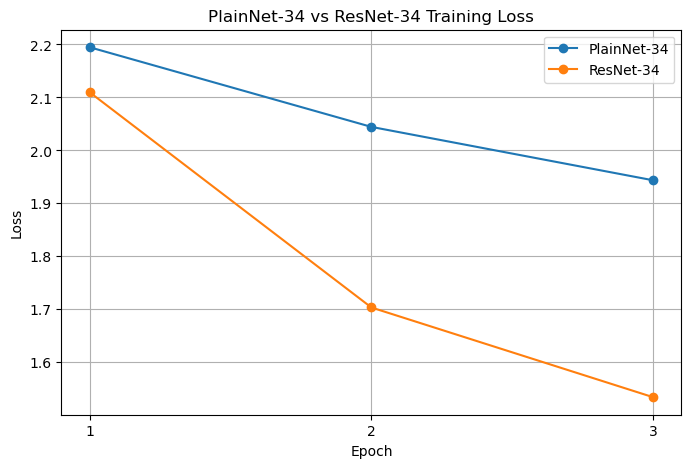

In [51]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(plain34_train_losses) + 1),
    plain34_train_losses,
    marker="o",
    label="PlainNet-34"
)

plt.plot(
    range(1, len(resnet34_train_losses) + 1),
    resnet34_train_losses,
    marker="o",
    label="ResNet-34"
)

plt.title("PlainNet-34 vs ResNet-34 Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(range(1, EPOCH + 1))
plt.grid()
plt.legend()
plt.show()

### 44.PlainNet-34 vs ResNet-34 Validation Accuracy

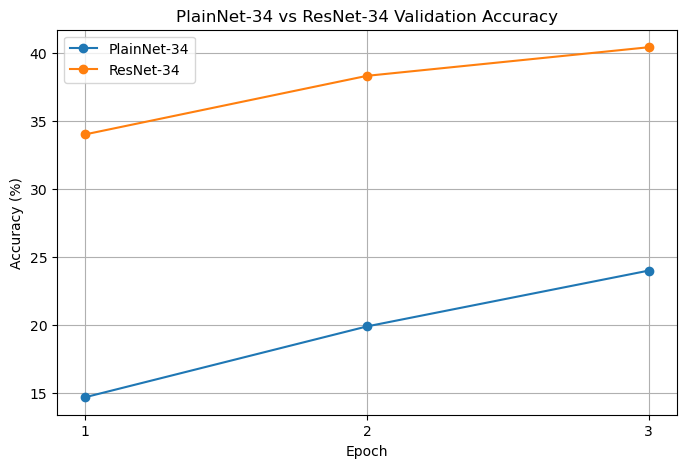

In [52]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(plain34_val_accuracy) + 1),
    plain34_val_accuracy,
    marker="o",
    label="PlainNet-34"
)

plt.plot(
    range(1, len(resnet34_val_accuracy) + 1),
    resnet34_val_accuracy,
    marker="o",
    label="ResNet-34"
)

plt.title("PlainNet-34 vs ResNet-34 Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.xticks(range(1, EPOCH + 1))
plt.grid()
plt.legend()
plt.show()

### 45.PlainNet-50 vs ResNet-50 Training Loss

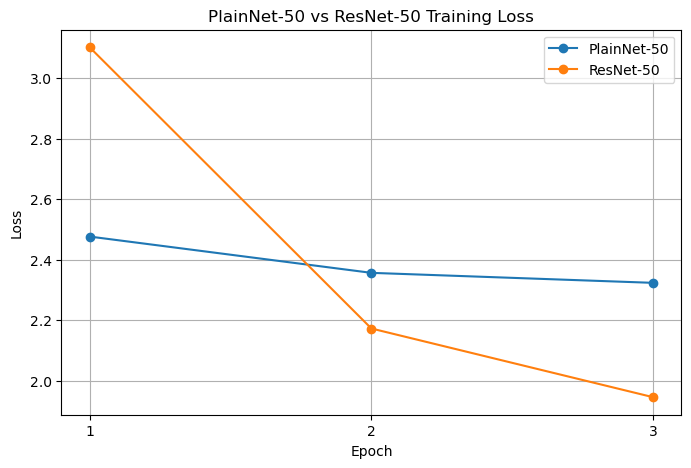

In [53]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(plain50_train_losses) + 1),
    plain50_train_losses,
    marker="o",
    label="PlainNet-50"
)

plt.plot(
    range(1, len(resnet50_train_losses) + 1),
    resnet50_train_losses,
    marker="o",
    label="ResNet-50"
)

plt.title("PlainNet-50 vs ResNet-50 Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(range(1, EPOCH + 1))
plt.grid()
plt.legend()
plt.show()

### 46.PlainNet-50 vs ResNet-50 Validation Accuracy

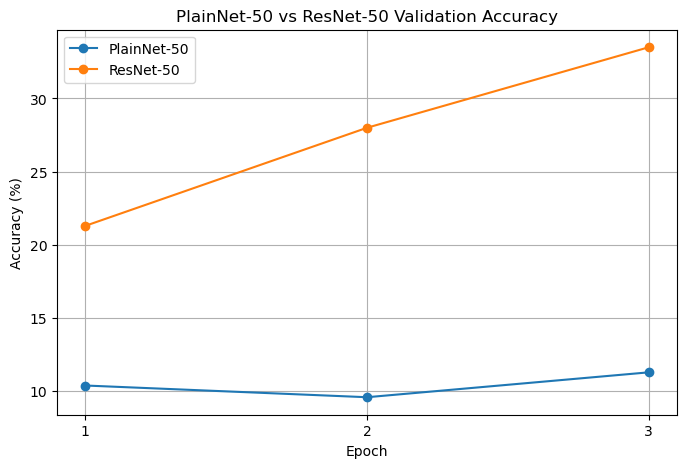

In [54]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(plain50_val_accuracy) + 1),
    plain50_val_accuracy,
    marker="o",
    label="PlainNet-50"
)

plt.plot(
    range(1, len(resnet50_val_accuracy) + 1),
    resnet50_val_accuracy,
    marker="o",
    label="ResNet-50"
)

plt.title("PlainNet-50 vs ResNet-50 Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.xticks(range(1, EPOCH + 1))
plt.grid()
plt.legend()
plt.show()

### 47.모든 모델 Training Loss 비교

/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


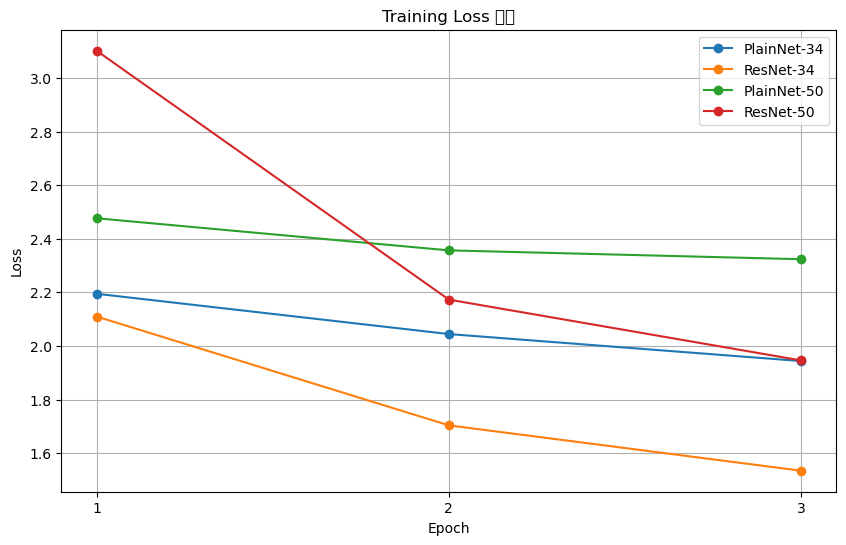

In [55]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(plain34_train_losses) + 1),
    plain34_train_losses,
    marker="o",
    label="PlainNet-34"
)

plt.plot(
    range(1, len(resnet34_train_losses) + 1),
    resnet34_train_losses,
    marker="o",
    label="ResNet-34"
)

plt.plot(
    range(1, len(plain50_train_losses) + 1),
    plain50_train_losses,
    marker="o",
    label="PlainNet-50"
)

plt.plot(
    range(1, len(resnet50_train_losses) + 1),
    resnet50_train_losses,
    marker="o",
    label="ResNet-50"
)

plt.title("Training Loss 비교")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(range(1, EPOCH + 1))
plt.grid()
plt.legend()
plt.show()

### 48.모든 모델 Validation Accuracy 비교

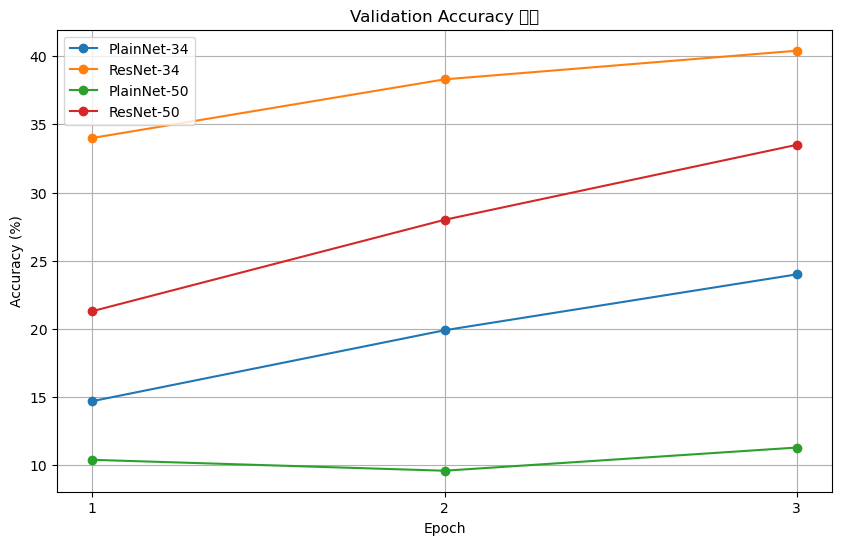

In [56]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(plain34_val_accuracy) + 1),
    plain34_val_accuracy,
    marker="o",
    label="PlainNet-34"
)

plt.plot(
    range(1, len(resnet34_val_accuracy) + 1),
    resnet34_val_accuracy,
    marker="o",
    label="ResNet-34"
)

plt.plot(
    range(1, len(plain50_val_accuracy) + 1),
    plain50_val_accuracy,
    marker="o",
    label="PlainNet-50"
)

plt.plot(
    range(1, len(resnet50_val_accuracy) + 1),
    resnet50_val_accuracy,
    marker="o",
    label="ResNet-50"
)

plt.title("Validation Accuracy 비교")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.xticks(range(1, EPOCH + 1))
plt.grid()
plt.legend()
plt.show()

### 49.첫 Loss와 마지막 Loss 비교

In [57]:
print("학습 손실 비교")
print("-" * 50)

print(
    f"PlainNet-34: "
    f"{plain34_train_losses[0]:.4f} "
    f"→ {plain34_train_losses[-1]:.4f}"
)

print(
    f"ResNet-34: "
    f"{resnet34_train_losses[0]:.4f} "
    f"→ {resnet34_train_losses[-1]:.4f}"
)

print(
    f"PlainNet-50: "
    f"{plain50_train_losses[0]:.4f} "
    f"→ {plain50_train_losses[-1]:.4f}"
)

print(
    f"ResNet-50: "
    f"{resnet50_train_losses[0]:.4f} "
    f"→ {resnet50_train_losses[-1]:.4f}"
)

학습 손실 비교
--------------------------------------------------
PlainNet-34: 2.1947 → 1.9436
ResNet-34: 2.1098 → 1.5342
PlainNet-50: 2.4767 → 2.3237
ResNet-50: 3.1021 → 1.9459


### 50.Loss 감소 여부 확인

In [58]:
print("학습 손실이 감소하였나?")
print("-" * 50)

print(
    "PlainNet-34:",
    plain34_train_losses[-1]
    < plain34_train_losses[0]
)

print(
    "ResNet-34:",
    resnet34_train_losses[-1]
    < resnet34_train_losses[0]
)

print(
    "PlainNet-50:",
    plain50_train_losses[-1]
    < plain50_train_losses[0]
)

print(
    "ResNet-50:",
    resnet50_train_losses[-1]
    < resnet50_train_losses[0]
)

학습 손실이 감소하였나?
--------------------------------------------------
PlainNet-34: True
ResNet-34: True
PlainNet-50: True
ResNet-50: True


### 51.최종 Validation Accuracy 확인

In [59]:
final_accuracy = {
    "PlainNet-34": plain34_val_accuracy[-1],
    "ResNet-34": resnet34_val_accuracy[-1],
    "PlainNet-50": plain50_val_accuracy[-1],
    "ResNet-50": resnet50_val_accuracy[-1]
}

print("Final Validation Accuracy")
print("-" * 50)

for model_name, accuracy in final_accuracy.items():
    print(
        f"{model_name}: "
        f"{accuracy:.2f}%"
    )

Final Validation Accuracy
--------------------------------------------------
PlainNet-34: 24.00%
ResNet-34: 40.40%
PlainNet-50: 11.30%
ResNet-50: 33.50%


## Ablation Study

34-layer와 50-layer 모델의 Validation Accuracy를 비교하여 Residual Connection의 효과를 분석한다.
동일한 학습 조건에서 PlainNet과 ResNet의 성능 차이를 확인하였다.

### 52.Ablation Study 결과 표

In [60]:
ablation_result = pd.DataFrame({
    "Model Depth": [
        34,
        34,
        50,
        50
    ],

    "Model": [
        "PlainNet-34",
        "ResNet-34",
        "PlainNet-50",
        "ResNet-50"
    ],

    "Block Type": [
        "Basic Plain Block",
        "Basic Residual Block",
        "Bottleneck Plain Block",
        "Bottleneck Residual Block"
    ],

    "Epoch": [
        EPOCH,
        EPOCH,
        EPOCH,
        EPOCH
    ],

    "First Training Loss": [
        plain34_train_losses[0],
        resnet34_train_losses[0],
        plain50_train_losses[0],
        resnet50_train_losses[0]
    ],

    "Final Training Loss": [
        plain34_train_losses[-1],
        resnet34_train_losses[-1],
        plain50_train_losses[-1],
        resnet50_train_losses[-1]
    ],

    "Final Validation Accuracy (%)": [
        plain34_val_accuracy[-1],
        resnet34_val_accuracy[-1],
        plain50_val_accuracy[-1],
        resnet50_val_accuracy[-1]
    ]
})

ablation_result

,Model Depth,Model,Block Type,Epoch,First Training Loss,Final Training Loss,Final Validation Accuracy (%)
0,34,PlainNet-34,Basic Plain Block,3,2.194714,1.943555,24.0
1,34,ResNet-34,Basic Residual Block,3,2.109808,1.534154,40.4
2,50,PlainNet-50,Bottleneck Plain Block,3,2.476650,2.323737,11.3
3,50,ResNet-50,Bottleneck Residual Block,3,3.102128,1.945892,33.5


### 53.Residual Connection 정확도 차이

In [62]:
accuracy_difference_34 = (
    resnet34_val_accuracy[-1]
    - plain34_val_accuracy[-1]
)

accuracy_difference_50 = (
    resnet50_val_accuracy[-1]
    - plain50_val_accuracy[-1]
)

print("Effect of Residual Connection")
print("-" * 50)

print(
    f"34-layer accuracy difference: "
    f"{accuracy_difference_34:+.2f}%p"
)

print(
    f"50-layer accuracy difference: "
    f"{accuracy_difference_50:+.2f}%p"
)

Effect of Residual Connection
--------------------------------------------------
34-layer accuracy difference: +16.40%p
50-layer accuracy difference: +22.20%p


### 54.가장 높은 정확도의 모델

In [63]:
best_model = max(
    final_accuracy,
    key=final_accuracy.get
)

best_accuracy = final_accuracy[
    best_model
]

print(
    f"Best Model: {best_model}"
)

print(
    f"Best Validation Accuracy: "
    f"{best_accuracy:.2f}%"
)

Best Model: ResNet-34
Best Validation Accuracy: 40.40%


### 55.최종 Validation Accuracy 막대그래프

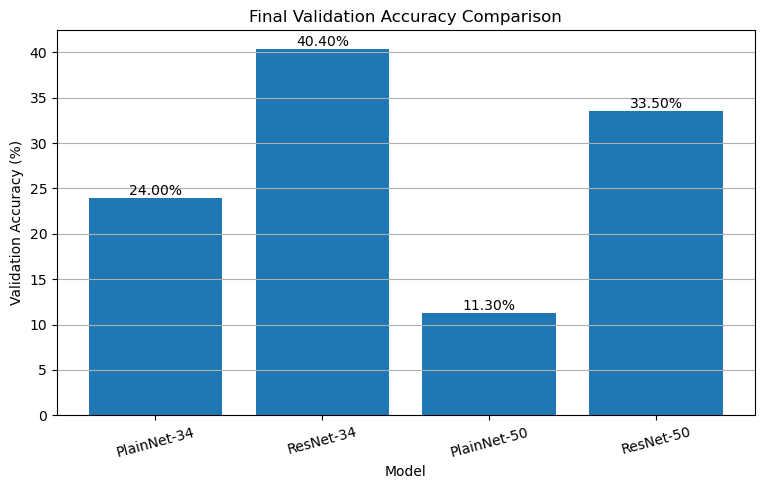

In [64]:
model_names = list(
    final_accuracy.keys()
)

accuracy_values = list(
    final_accuracy.values()
)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    model_names,
    accuracy_values
)

plt.title(
    "Final Validation Accuracy Comparison"
)

plt.xlabel("Model")
plt.ylabel("Validation Accuracy (%)")
plt.xticks(rotation=15)
plt.grid(axis="y")

for bar, accuracy in zip(
    bars,
    accuracy_values
):
    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        f"{accuracy:.2f}%",
        ha="center",
        va="bottom"
    )

plt.show()

## 수정사항

실행 환경이 CPU였기 때문에 학습 시간이 매우 오래 걸리는 문제가 발생하였다. 이를 해결하기 위해 다음과 같은 사항을 수정하였다.

1.학습 데이터셋 축소
-> 원래 CIFAR-10의 전체 학습 데이터(50000장)와 테스트 데이터(10000장)를 사용하였으나, 실행 시간을 줄이기 위해 Subset을 이용하여 학습 데이터 5000장과 테스트 데이터 1000장만 사용하였다.또한,모든 모델(PlainNet-34, ResNet-34, PlainNet-50, ResNet-50)에 동일한 데이터셋을 적용하여 비교의 공정성을 유지하였다.
    
2.Batch size,Epoch 감소
-> CPU 환경에서 네 개의 모델을 모두 학습하기에는 시간이 오래 소요되므로 Batch size를 줄이고 Epoch 수를 줄여 전체 학습 시간을 단축하였다.
    
3.DataLoader 설정 수정
-> num_workers=0으로 설정하여 Jupyter Notebook 환경에서 안정적으로 데이터를 불러오도록 하였다.
    
4.학습 진행 상황 출력 개선
-> 기존에는 일정 배치(batch) 이후에만 진행 상황이 출력되어 학습이 멈춘 것처럼 보였다.
첫 번째 배치부터 일정 간격마다 Loss를 출력하도록 수정하여 학습 진행 여부를 쉽게 확인할 수 있도록 하였다.
    
5.메모리 관리
-> 각 Epoch 종료 후 gc.collect()를 호출하여 사용하지 않는 메모리를 정리함으로써 장시간 학습 시 메모리 사용을 안정적으로 유지하였다.

## 결론

## 1. Experimental Setup

본 실험에서는 CIFAR-10 데이터셋을 이용하여 PlainNet과 ResNet의 성능을 비교하였다.

비교한 모델은 다음과 같다.

- PlainNet-34
- ResNet-34
- PlainNet-50
- ResNet-50

PlainNet과 ResNet의 차이는 residual connection의 사용 여부이다.
34-layer 모델에는 Basic Block을 사용하였고, 50-layer 모델에는 Bottleneck Block을 사용하였다.

모든 모델에는 동일한 batch size, epoch, learning rate, optimizer와 데이터셋을 적용하였다.

학습에 앞서 CIFAR-10 데이터셋의 클래스 수와 클래스 이름을 확인하고, 학습 데이터와 테스트 데이터의 개수를 확인하였다. 또한 DataLoader를 구성한 후 실제 학습에 사용되는 학습 샘플 수, 테스트 샘플 수 및 배치 수를 확인하여 데이터셋이 올바르게 구성되었는지 검증하였다.CIFAR-10의 원본 데이터셋은 학습 데이터 50,000장과 테스트 데이터 10,000장으로 구성되어 있다. 본 실험에서는 CPU 환경에서의 학습 시간을 고려하여 학습 데이터 5,000장과 테스트 데이터 1,000장을 선택하여 모든 모델에 동일하게 적용하였다.

CPU 실행 환경으로 인해 학습 시간을 줄이기 위해 CIFAR-10 데이터셋의 일부를 사용하였고, 모든 모델이 동일한 학습 데이터와 테스트 데이터를 사용하도록 설정하여 비교 조건을 동일하게 유지하였다.

## 2. Training Loss

네 모델 모두 학습이 진행되면서 training loss가 감소하는 경향을 보였다.

이는 optimizer를 통한 parameter update가 정상적으로 이루어졌으며, 각 모델이 학습 데이터의 특징을 학습하고 있음을 의미한다.

PlainNet과 ResNet의 loss 감소 속도와 최종 loss를 비교하여 residual connection이 최적화에 어떤 영향을 주었는지 확인하였다.

## 3. Validation Accuracy

34-layer 모델에서는 ResNet-34와 PlainNet-34의 성능을 비교하였고, 50-layer 모델에서는 ResNet-50과 PlainNet-50의 성능을 비교하였다.

## 4. Effect of Residual Connection

Residual connection은 입력을 여러 convolution layer를 거친 출력에 직접 더해준다.

y = F(x) + x

여기서 x는 block의 입력이고, F(x)는 convolution layer가 학습한 residual mapping이다.

Residual connection은 gradient가 깊은 network의 앞부분까지 더 쉽게 전달될 수 있도록 도와준다. 따라서 network가 깊어질 때 발생할 수 있는 degradation problem과 gradient vanishing 문제를 완화할 수 있다.

실험 결과에서 ResNet의 validation accuracy가 PlainNet보다 높고 loss가 안정적으로 감소했다면 residual connection이 깊은 network의 학습을 효과적으로 도왔다고 해석할 수 있다.

반대로 제한된 epoch 또는 축소된 데이터셋에서 PlainNet의 성능이 더 높게 측정될 수도 있다. 이러한 경우에는 residual connection이 효과가 없다고 단정하기보다, 짧은 학습 시간과 제한된 데이터가 결과에 영향을 주었을 가능성을 고려해야 한다.

## 5. Final Result

본 실험을 통해 동일한 깊이를 가진 PlainNet과 ResNet을 비교하고 residual connection이 deep neural network의 학습에 미치는 영향을 확인하였다.

ResNet은 skip connection을 통해 gradient 전달을 개선하고 깊은 network의 최적화를 용이하게 하는 구조이다.

실험에서 가장 높은 validation accuracy를 기록한 모델은 실행 결과에서 확인된 best model이다.

## 회고

이번달 프로젝트 과제중 가장 복잡하고 시간이 오래걸렸던 과제였다. 데이터셋을 이용해 어떻게 이용하는지 또한 어떤걸 비교해서 영향을 확인할 수 있는지 알 수 있는 과제였다. flow를 확인할 수 있었다고 본다.
그러나 시간 때문에 세세하게 검증하는 그런 과정을 거친것이 아니기 때문에 다음에는 논문구조에 맞는 좀 더 정확하고 세밀한 구조로 설계하여 프로젝트 수행해야 할 것 같고, 더 명확히 이해하기 위해 복습과정을 거쳐야 할 것 같다.